# Cross Validation Project

A single train-test split can feel comforting because it gives us a number.

But one number can lie.

Maybe the split was easy. Maybe it was harsh. Maybe one group of unusual customers landed in the test set and made a good model look bad. Maybe the opposite happened, and a fragile model got lucky.

This project is about the reason ML models can be trusted: not because they scored well once, but because they were tested repeatedly and stayed reliable.

> A single train-test split can lie to you. Cross Validation helps you see the bigger picture.

## 1. Problem Statement

Evaluating machine learning models is difficult because the future is hidden.

We train on historical customers, but the business question is about future customers. We can measure accuracy on one test split, but that split is only one possible version of reality.

In this project, we predict telecom customer churn and investigate a deeper question:

> Is this model genuinely reliable, or did it just get a favorable split?

Trust in ML predictions matters because business decisions follow the model: retention campaigns, customer outreach, budget allocation, and product strategy. A model that only looks good once is not enough.

## 2. The Hidden Problem With Train-Test Split

A train-test split is like judging a student from one exam.

If the exam happens to cover the exact chapters the student studied, the student looks stronger than they are. If it covers their weakest topics, they look worse than they are.

The same thing happens with models.

One split can be lucky. One split can be unlucky. Customer churn data has different customer types: month-to-month customers, long-tenure customers, fiber internet customers, high-charge customers, low-charge customers. Depending on how those customers land in train and test, the score can move.

That movement is not noise to ignore. It is information about reliability.

## 3. Dataset Overview

Dataset: IBM Telco Customer Churn dataset already used in the GraphX Labs portfolio.

Rows: 7,043 customers

Target variable: `churn`

Business interpretation:

- `1`: customer churned
- `0`: customer stayed

The dataset includes numerical features such as tenure and monthly charges, plus categorical features such as contract type, internet service, payment method, and support services.

This makes it a strong dataset for cross-validation because it has enough rows, class imbalance, mixed feature types, and real evaluation risk.

## 4. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

from src.preprocessing.data_preprocessing import TARGET_COLUMN, load_telco_dataset, save_processed, split_features_target
from src.experiments.model_experiments import logistic_model, decision_tree_model, random_forest_model
from src.evaluation.metrics import evaluate_classifier, summarize_scores
from src.validation.cross_validation import repeated_train_test_scores, fold_scores, fold_class_balance, kfold, stratified_kfold
from src.tuning.grid_search import tune_decision_tree
from src.visualization.plots import (
    plot_repeated_splits,
    plot_fold_scores,
    plot_score_boxplot,
    plot_kfold_visualization,
    plot_learning_curves,
    plot_validation_curves,
)

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 5. Load Dataset

In [2]:
raw_path = PROJECT_ROOT / "data/raw/telco_customer_churn.csv"
processed_path = PROJECT_ROOT / "data/processed/telco_customer_churn_processed.csv"

df = save_processed(raw_path, processed_path)
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 6. Initial Data Inspection

Before validation, we inspect the data. Cross-validation cannot rescue a messy modeling setup. It can only estimate reliability for the pipeline we give it.

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(8))
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion"))
df.info()

Shape: (7043, 20)

Missing values:
totalcharges        11
gender               0
seniorcitizen        0
monthlycharges       0
paymentmethod        0
paperlessbilling     0
contract             0
streamingmovies      0
dtype: int64

Target distribution:
0    0.73463
1    0.26537
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprote

## 7. Exploratory Data Analysis

The churn target is imbalanced: most customers stay, fewer customers leave. This matters because ordinary KFold can create folds with slightly different churn rates. StratifiedKFold is designed to preserve that distribution.

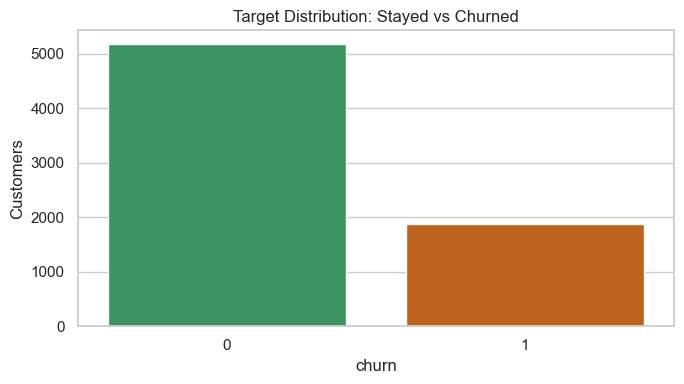

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COLUMN, palette=["#2ca25f", "#d95f02"])
plt.title("Target Distribution: Stayed vs Churned")
plt.xlabel("churn")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

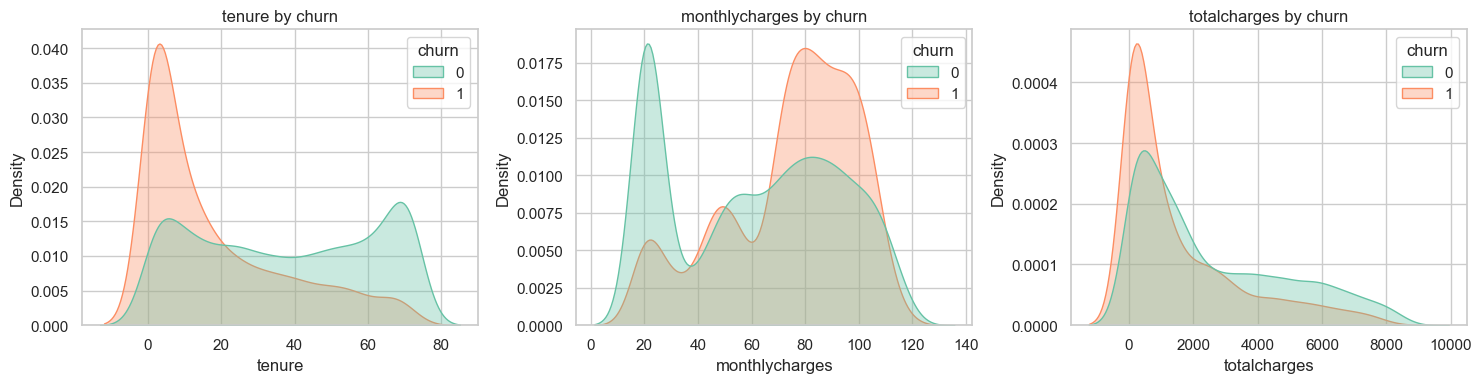

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "monthlycharges", "totalcharges"]):
    sns.kdeplot(data=df, x=col, hue=TARGET_COLUMN, fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

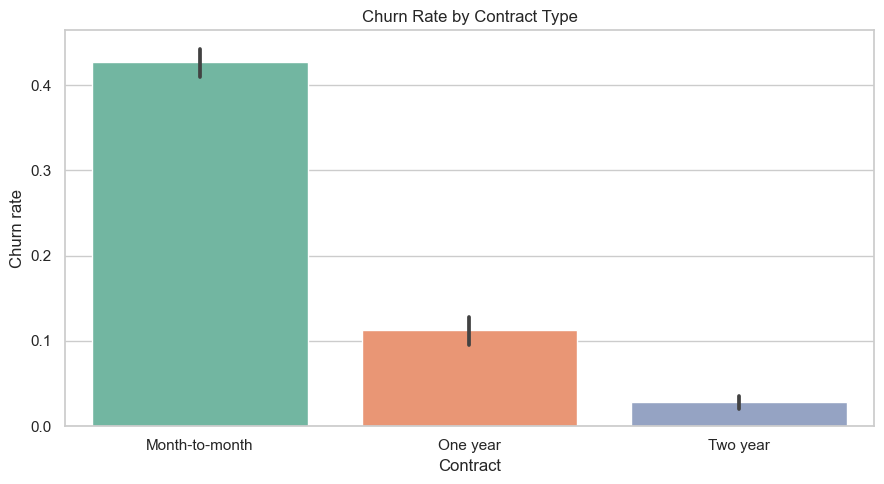

In [6]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="contract", y=TARGET_COLUMN, estimator=np.mean, palette="Set2")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "contract_churn_rate.png", dpi=160, bbox_inches="tight")
plt.show()

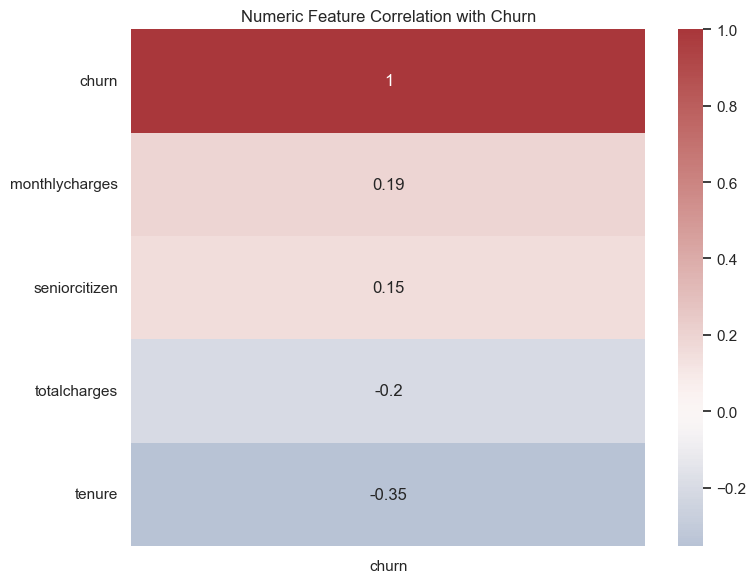

In [7]:
numeric_corr = df.select_dtypes(include=["int64", "float64"]).corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr[[TARGET_COLUMN]].sort_values(TARGET_COLUMN, ascending=False), cmap="vlag", center=0, annot=True)
plt.title("Numeric Feature Correlation with Churn")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Baseline Train-Test Split

We begin the way many projects begin: one split, one model, one score.

Then we repeat the split with different random seeds.

This section is meant to make the weakness of a single split visible. If the score moves when the split changes, the single score was never the whole truth.

In [8]:
X, y = split_features_target(df)
base_model = logistic_model(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
baseline_result = evaluate_classifier(base_model, X_train, X_test, y_train, y_test, "Single Split Logistic Regression")
pd.DataFrame([baseline_result]).round(4)

,model,train_accuracy,test_accuracy,generalization_gap,precision,recall,f1,roc_auc
0,Single Split Logistic Regression,0.7493,0.7501,-0.0008,0.5188,0.7966,0.6284,0.846


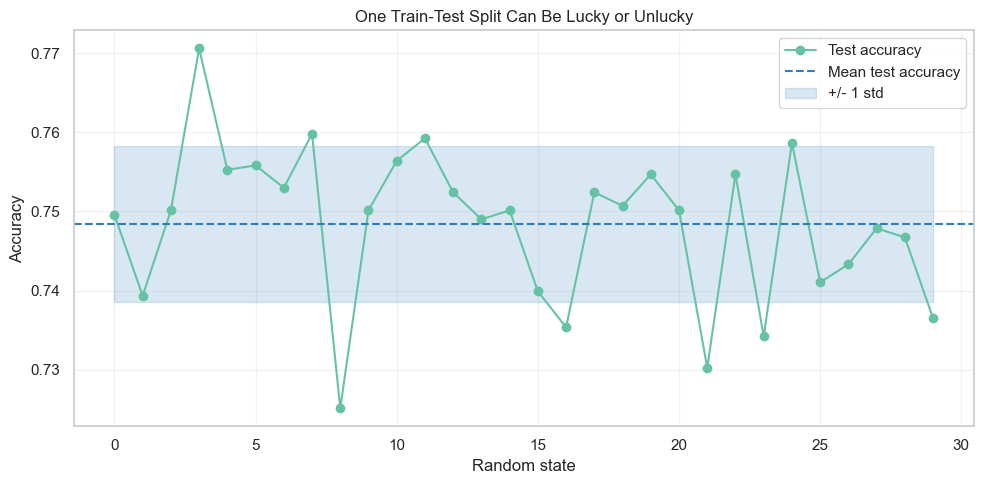

,random_state,train_accuracy,test_accuracy,generalization_gap
count,30.0000,30.0000,30.0000,30.0000
mean,14.5000,0.7504,0.7484,0.0020
std,8.8034,0.0034,0.0098,0.0114
min,0.0000,0.7431,0.7252,-0.0195
25%,7.2500,0.7493,0.7416,-0.0057
50%,14.5000,0.7504,0.7501,-0.0002
75%,21.7500,0.7524,0.7547,0.0100
max,29.0000,0.7573,0.7706,0.0308


In [9]:
split_results = repeated_train_test_scores(logistic_model(X), X, y, random_states=range(30), test_size=0.25)
plot_repeated_splits(split_results, IMAGES_DIR / "train_test_instability.png")
plt.show()
split_results.describe().round(4)

## 9. What Is Cross Validation?

Cross Validation is repeated validation.

Instead of asking the model to prove itself on one split, we ask it to prove itself across several splits. Each fold takes a turn as validation data. The model trains repeatedly, validates repeatedly, and gives us a distribution of scores.

That distribution is the point.

Cross Validation estimates how reliable a model really is.

## 10. K-Fold Cross Validation

KFold splits the dataset into `k` parts. The model trains on `k-1` folds and validates on the remaining fold. This repeats until every fold has served as validation data.

The average score tells us typical performance. The standard deviation tells us stability.

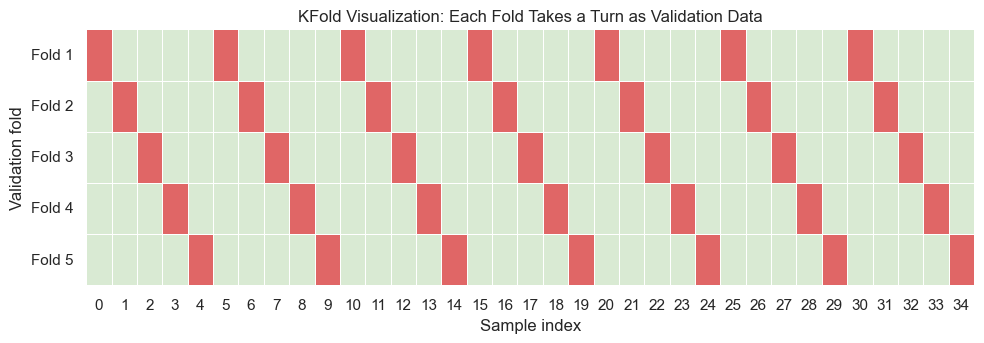

In [10]:
plot_kfold_visualization(n_samples=35, n_splits=5, output_path=IMAGES_DIR / "kfold_visualization.png")
plt.show()

In [11]:
kf = kfold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = fold_scores(logistic_model(X), X, y, kf, label="Logistic Regression KFold")
kfold_scores.round(4)

,model,fold,score
0,Logistic Regression KFold,1,0.7488
1,Logistic Regression KFold,2,0.7601
2,Logistic Regression KFold,3,0.7339
3,Logistic Regression KFold,4,0.7450
4,Logistic Regression KFold,5,0.7429


## 11. Stratified K-Fold

StratifiedKFold is especially important for classification.

If churned customers are the minority class, each validation fold should preserve roughly the same churn rate. Otherwise, one fold may be easier or harder simply because it has a different class mix.

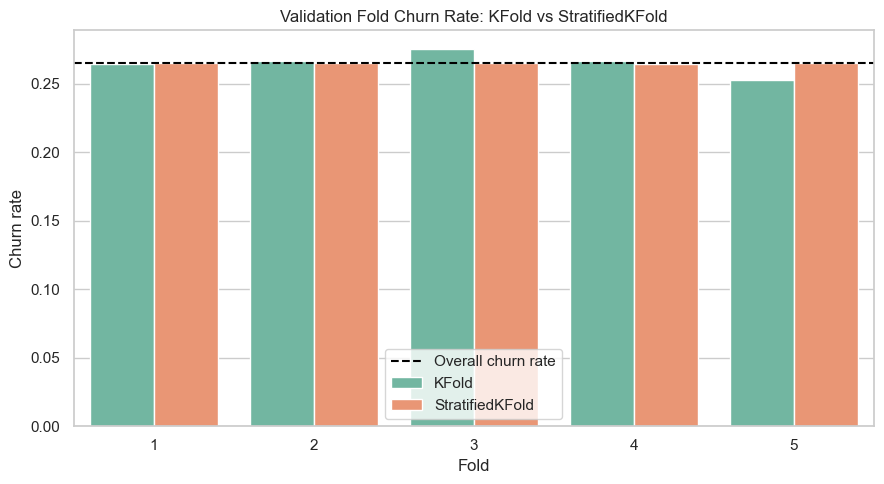

,method,fold,validation_churn_rate,validation_size
0,KFold,1,0.2647,1409
1,KFold,2,0.2669,1409
2,KFold,3,0.2754,1409
3,KFold,4,0.2670,1408
4,KFold,5,0.2528,1408
5,StratifiedKFold,1,0.2654,1409
6,StratifiedKFold,2,0.2654,1409
7,StratifiedKFold,3,0.2654,1409
8,StratifiedKFold,4,0.2649,1408
9,StratifiedKFold,5,0.2656,1408


In [12]:
skf = stratified_kfold(n_splits=5, shuffle=True, random_state=42)

balance_df = pd.concat([
    fold_class_balance(y, kf, "KFold"),
    fold_class_balance(y, skf, "StratifiedKFold"),
], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.barplot(data=balance_df, x="fold", y="validation_churn_rate", hue="method")
plt.axhline(y.mean(), color="black", linestyle="--", label="Overall churn rate")
plt.title("Validation Fold Churn Rate: KFold vs StratifiedKFold")
plt.xlabel("Fold")
plt.ylabel("Churn rate")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "stratified_kfold_balance.png", dpi=160, bbox_inches="tight")
plt.show()
balance_df.round(4)

## 12. Cross Validation Scores

Now we compare multiple models using StratifiedKFold.

Reliability is not just the best score. A model with slightly lower average performance but much lower variance may be more trustworthy in production.

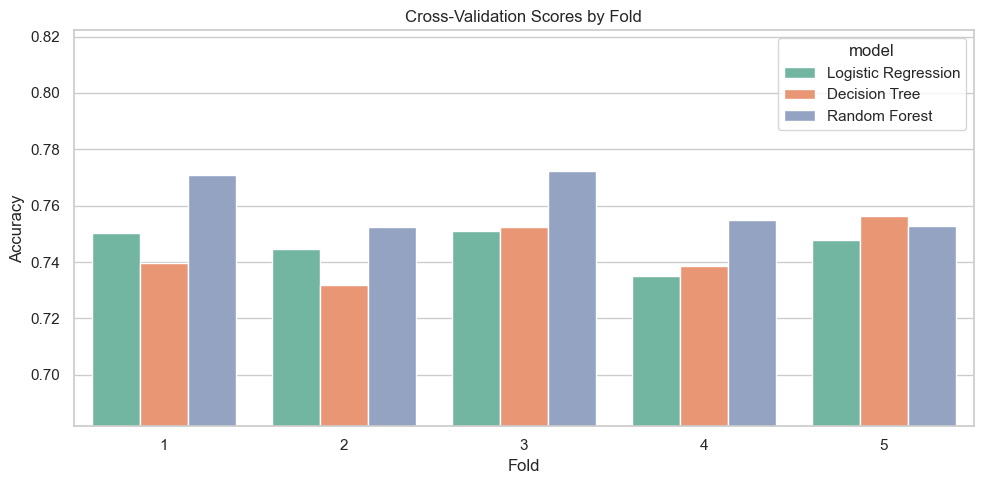

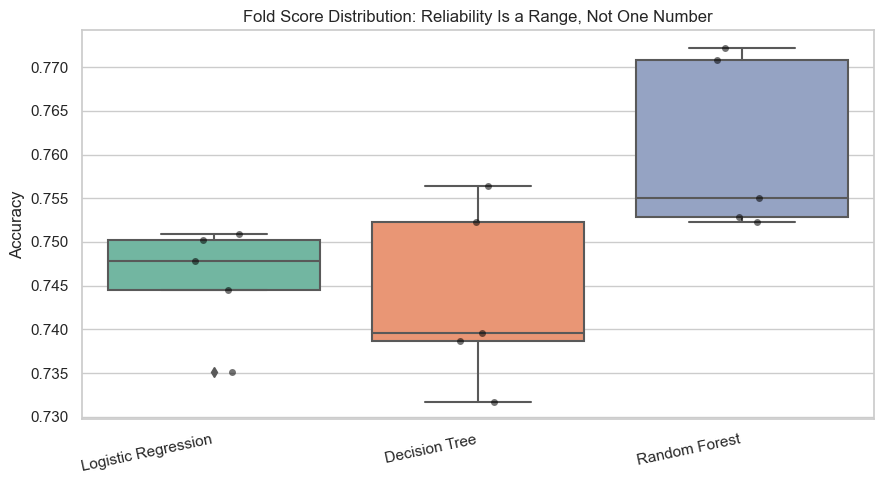

,model,mean_score,std_score,min_score,max_score,range
2,Random Forest,0.7606,0.0100,0.7523,0.7722,0.0199
0,Logistic Regression,0.7457,0.0064,0.7351,0.7509,0.0158
1,Decision Tree,0.7437,0.0103,0.7317,0.7564,0.0247


In [13]:
models = {
    "Logistic Regression": logistic_model(X),
    "Decision Tree": decision_tree_model(X, max_depth=4, min_samples_leaf=25),
    "Random Forest": random_forest_model(X, n_estimators=180, max_depth=8, min_samples_leaf=10),
}

score_frames = []
summary_rows = []
for name, model in models.items():
    scores_df = fold_scores(model, X, y, skf, label=name)
    score_frames.append(scores_df)
    summary_rows.append(summarize_scores(scores_df["score"], name))

cv_scores = pd.concat(score_frames, ignore_index=True)
cv_summary = pd.DataFrame(summary_rows).sort_values("mean_score", ascending=False)

plot_fold_scores(cv_scores, IMAGES_DIR / "cross_validation_scores.png")
plt.show()
plot_score_boxplot(cv_scores, IMAGES_DIR / "fold_score_boxplot.png")
plt.show()
cv_summary.round(4)

## 13. Why Variance Across Folds Matters

The mean score answers: how good is the model on average?

The standard deviation answers: how much does the score move when the validation data changes?

A high standard deviation is a warning sign. It means the model may be sensitive to the exact customer sample. In production, sensitivity becomes risk.

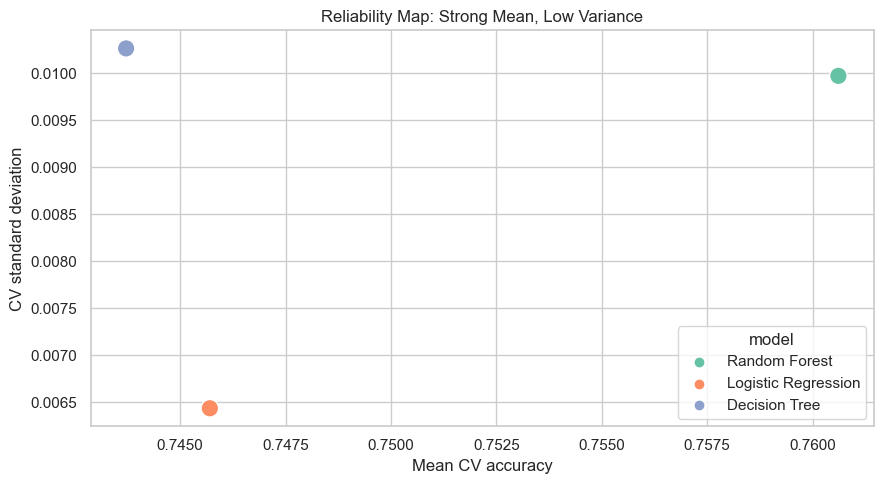

In [14]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=cv_summary, x="mean_score", y="std_score", hue="model", s=160)
plt.title("Reliability Map: Strong Mean, Low Variance")
plt.xlabel("Mean CV accuracy")
plt.ylabel("CV standard deviation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "model_reliability_map.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Cross Validation for Hyperparameter Tuning

Tuning on one split is risky because the chosen hyperparameters may be optimized for one lucky partition.

GridSearchCV evaluates hyperparameters across folds. It asks a more mature question:

> Which settings work consistently, not just once?

In [15]:
tree_for_tuning = decision_tree_model(X)
search = tune_decision_tree(tree_for_tuning, X, y, skf, scoring="accuracy")
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))

tuning_results = pd.DataFrame(search.cv_results_)
tuning_results[["param_model__max_depth", "param_model__min_samples_leaf", "mean_train_score", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).head(10).round(4)

Best parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 1}
Best CV accuracy: 0.7437


,param_model__max_depth,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score
14,4,50,0.7529,0.7437,0.0092
10,4,1,0.7529,0.7437,0.0092
11,4,5,0.7529,0.7437,0.0092
12,4,10,0.7529,0.7437,0.0092
13,4,25,0.7529,0.7437,0.0092
5,3,1,0.7420,0.7413,0.0111
6,3,5,0.7420,0.7413,0.0111
7,3,10,0.7420,0.7413,0.0111
8,3,25,0.7420,0.7413,0.0111
9,3,50,0.7420,0.7413,0.0111


## 15. Cross Validation and Overfitting

Cross-validation exposes overfitting by comparing training scores with validation scores during tuning.

If training score rises while validation score stalls or falls, the model is becoming better at rehearsal than reality.

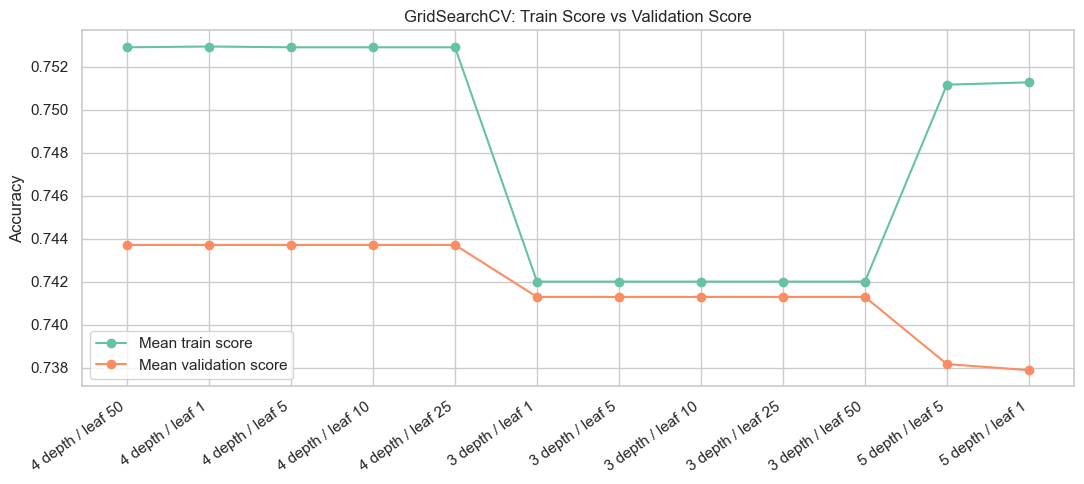

In [16]:
top_tuning = tuning_results.copy()
top_tuning["complexity"] = top_tuning["param_model__max_depth"].astype(str) + " depth / leaf " + top_tuning["param_model__min_samples_leaf"].astype(str)
plot_df = top_tuning.sort_values("mean_test_score", ascending=False).head(12)

plt.figure(figsize=(11, 5))
plt.plot(range(len(plot_df)), plot_df["mean_train_score"], marker="o", label="Mean train score")
plt.plot(range(len(plot_df)), plot_df["mean_test_score"], marker="o", label="Mean validation score")
plt.xticks(range(len(plot_df)), plot_df["complexity"], rotation=35, ha="right")
plt.title("GridSearchCV: Train Score vs Validation Score")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "cv_overfitting_detection.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Learning Curves + Validation Curves

Learning curves show whether the model becomes more reliable as it sees more data.

Validation curves show how performance changes as a hyperparameter changes.

Together, they help diagnose underfitting, overfitting, and instability.

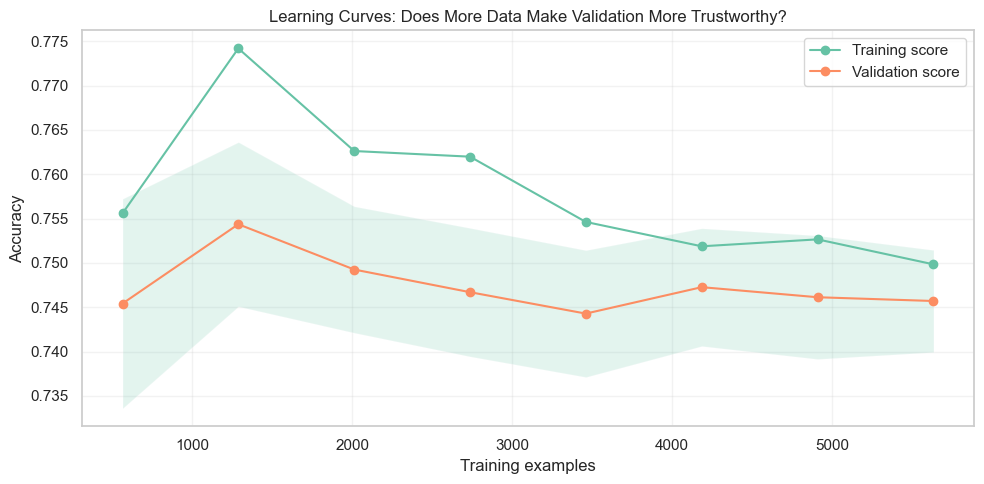

In [17]:
plot_learning_curves(logistic_model(X), X, y, skf, output_path=IMAGES_DIR / "learning_curves.png")
plt.show()

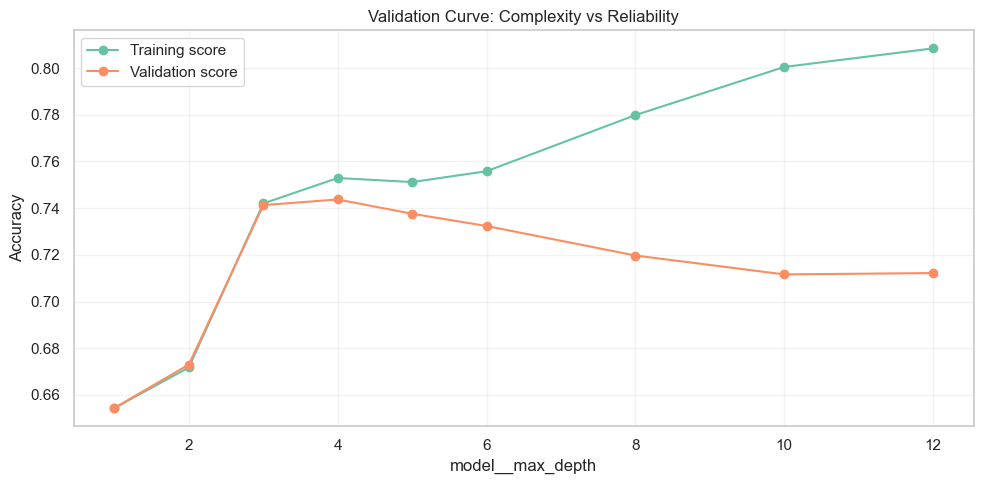

In [18]:
depth_range = [1, 2, 3, 4, 5, 6, 8, 10, 12]
plot_validation_curves(
    decision_tree_model(X, min_samples_leaf=10),
    X,
    y,
    skf,
    param_name="model__max_depth",
    param_range=depth_range,
    output_path=IMAGES_DIR / "validation_curves.png",
)
plt.show()

## 17. Practical ML Validation Workflow

A real-world validation workflow is not one score at the end of a notebook.

A practical workflow looks like this:

1. Keep a final test set untouched for the last check.
2. Use cross-validation on the training data for model comparison and tuning.
3. Inspect mean performance and variance.
4. Check learning curves and validation curves.
5. Watch for leakage and unstable folds.
6. Choose a model that is not only strong, but stable.
7. Evaluate once on the final test set before production.

Production models require robust validation because business decisions need consistency, not lucky numbers.

## 18. Final Model Comparison

We compare four evaluation views:

- one single split
- KFold Cross Validation
- StratifiedKFold Cross Validation
- tuned Decision Tree with CV

The lesson is that Cross Validation gives us a fuller picture than one test score.

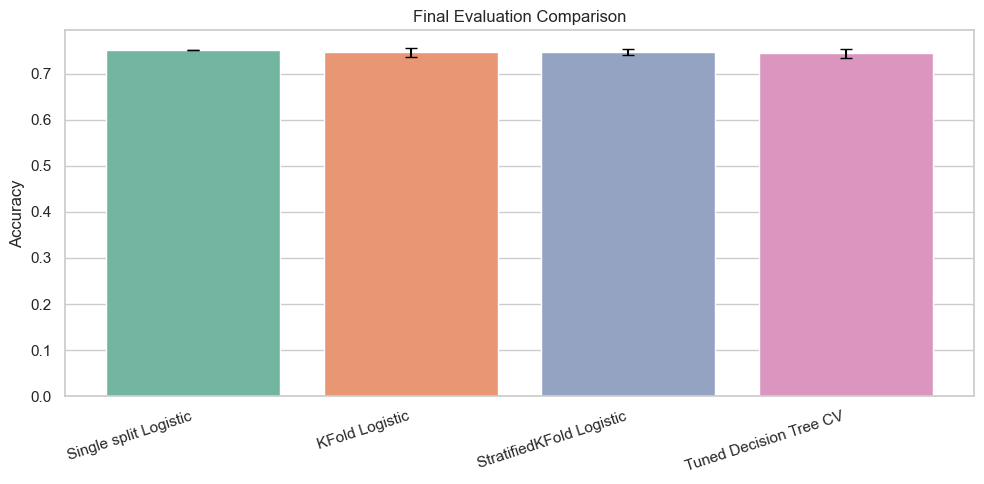

,evaluation,mean_score,std_score
0,Single split Logistic,0.7501,NaN
1,KFold Logistic,0.7461,0.0096
2,StratifiedKFold Logistic,0.7457,0.0064
3,Tuned Decision Tree CV,0.7437,0.0092


In [19]:
final_rows = [
    {"evaluation": "Single split Logistic", "mean_score": baseline_result["test_accuracy"], "std_score": np.nan},
    {"evaluation": "KFold Logistic", "mean_score": kfold_scores["score"].mean(), "std_score": kfold_scores["score"].std()},
    {"evaluation": "StratifiedKFold Logistic", "mean_score": cv_scores.loc[cv_scores["model"] == "Logistic Regression", "score"].mean(), "std_score": cv_scores.loc[cv_scores["model"] == "Logistic Regression", "score"].std()},
    {"evaluation": "Tuned Decision Tree CV", "mean_score": search.best_score_, "std_score": tuning_results.loc[search.best_index_, "std_test_score"]},
]
final_comparison = pd.DataFrame(final_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_comparison, x="evaluation", y="mean_score", palette="Set2")
plt.errorbar(range(len(final_comparison)), final_comparison["mean_score"], yerr=final_comparison["std_score"].fillna(0), fmt="none", color="black", capsize=4)
plt.title("Final Evaluation Comparison")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "final_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
final_comparison.round(4)

## 19. Key Learnings

- One train-test split is only one version of reality.
- Repeated splits reveal evaluation variance.
- KFold rotates validation responsibility across folds.
- StratifiedKFold preserves class balance and is usually better for classification.
- Mean CV score estimates typical performance.
- CV standard deviation estimates stability.
- GridSearchCV tunes hyperparameters more reliably than one split.
- Learning curves and validation curves turn model evaluation into diagnosis.
- Production trust comes from consistency, not one impressive score.

## 20. Final Takeaway

Cross Validation is not just a statistical trick.

It is how we stop believing lucky numbers.

A single split can tell one story. Cross Validation lets the model face several versions of the data and asks whether the story still holds.

That is how model reliability begins.

## 21. Interview Questions

For detailed interview preparation, see:

`cross-validation/interview_questions.md`

The companion interview article explains the same ideas in practical ML engineering language.